In [ ]:
import requests
import pandas as pd
from IPython.display import display, HTML
import random

# ─────────────────────────────────────────────
# CONSTANTS & SCOUTER UI COLORS
# ─────────────────────────────────────────────
STAT_KEYS = ['power_level', 'ruthlessness', 'loyalty', 'technique']

FACTION_COLORS = {
    'Frieza Force': '#8A2BE2', 'Saiyan': '#FF4500',
    'Earthling (Deceased)': '#A9A9A9', 'Namekian': '#32CD32',
    'Default': '#555555'
}

SCOUTER_COLORS = {
    'power_level': '#FF3333', 'ruthlessness': '#FF8C00',
    'loyalty': '#9370DB', 'technique': '#4682B4'
}

# Core nodes for your graph simulation
TIMELINE_NODES = ['Goku', 'Raditz', 'Vegeta', 'Nappa']

# ... existing code ...
# ─────────────────────────────────────────────
# FANDOM API & ALTERNATIVE REALITY INJECTION
# ─────────────────────────────────────────────
def get_wiki_node(title: str):
    """Fetch summary data from the Dragon Ball Fandom API and apply alternative reality."""

    headers = {
        'User-Agent': 'HackHPC_AltReality_Sim/1.0 (your_email@example.com) python-requests'
    }

    # 1. FIXED URL: Added &redirects=1 to resolve Fandom page routing and missing bio issues
    url = f'https://dragonball.fandom.com/api.php?action=query&prop=extracts|pageimages&exintro=1&explaintext=1&pithumbsize=400&redirects=1&titles={title}&format=json'
    r = requests.get(url, headers=headers)

    if r.status_code != 200:
        print(f'❌ Timeline node not found: {title}  (status {r.status_code})')
        return None

    data = r.json()

    # 2. FIXED JSON PARSING: Dig into Fandom's nested 'pages' dictionary
    pages = data.get('query', {}).get('pages', {})
    page = list(pages.values())[0] if pages else {}

    row = {
        'name': page.get('title', title),
        'original_bio': page.get('extract', 'Bio data not found on Fandom.'),
        'thumbnail': page.get('thumbnail', {}).get('source', '')
    }

    # --- THE PERTURBATION: INJECTING THE ALTERNATIVE REALITY ---
    query = title.lower()

    if "goku" in query or "kakarot" in query:
        row['name'] = "Kakarot (Alt Reality)"
        row['factions'] = "Saiyan, Frieza Force"
        row['power_level'] = 250
        row['ruthlessness'] = 98
        row['loyalty'] = 85
        row['technique'] = 15
        row['bio'] = "A ruthless low-class Saiyan warrior. Having never suffered a head injury, he decimated Earth's population as a Great Ape. He now serves Frieza alongside his brother, Raditz."
    elif "raditz" in query:
        row['name'] = "Raditz"
        row['factions'] = "Saiyan, Frieza Force"
        row['power_level'] = 1500
        row['ruthlessness'] = 80
        row['loyalty'] = 90
        row['technique'] = 40
        row['bio'] = "Arrived on Earth in Age 761 to find it already successfully purged by Kakarot. The brothers reunited and returned to space to serve Frieza."
    elif "vegeta" in query:
        row['name'] = "Vegeta"
        row['factions'] = "Saiyan, Frieza Force"
        row['power_level'] = 18000
        row['ruthlessness'] = 95
        row['loyalty'] = 40
        row['technique'] = 85
        row['bio'] = "Prince of the destroyed Saiyan race. With Kakarot successfully clearing Earth, Vegeta continues to violently purge planets."
    elif "nappa" in query:
        row['name'] = "Nappa"
        row['factions'] = "Saiyan, Frieza Force"
        row['power_level'] = 4000
        row['ruthlessness'] = 85
        row['loyalty'] = 80
        row['technique'] = 60
        row['bio'] = "An elite Saiyan warrior. He travels alongside Vegeta, acting as the brutal muscle for their planetary purges."

    # --- NEW ADDITIONS FOR SCOPE ACCURACY ---
    elif "frieza" in query or "freeza" in query:
        row['name'] = "Lord Frieza"
        row['factions'] = "Frieza Force"
        row['power_level'] = 530000 # His canonical first form power
        row['ruthlessness'] = 100
        row['loyalty'] = 0
        row['technique'] = 90
        row['bio'] = "The undisputed tyrant of the universe. With Kakarot acting as a loyal grunt alongside Vegeta, Frieza's empire expands unchallenged. He remains completely unaware of Vegeta's brewing coup."
    elif "cell" in query or "gero" in query or "android" in query:
        row['name'] = "Project Cell (Aborted)"
        row['factions'] = "Red Ribbon Army (Deceased)"
        row['power_level'] = 0 # He does not exist
        row['ruthlessness'] = 0
        row['loyalty'] = 0
        row['technique'] = 0
        row['bio'] = "TIMELINE ANOMALY: Because Kakarot eradicated the Red Ribbon Army as a Great Ape years before Dr. Gero could gather combat data, the ultimate android project was abandoned. Cell was never created in this reality."
        row['thumbnail'] = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a2/Question_mark_alternate.svg/1200px-Question_mark_alternate.svg.png" # Blank image to represent non-existence

    else:
        # Default generator for other characters pulled from Fandom
        row['factions'] = "Unknown"
        row['power_level'] = random.randint(100, 5000)
        row['ruthlessness'] = random.randint(10, 90)
        row['loyalty'] = random.randint(10, 90)
        row['technique'] = random.randint(10, 90)
        row['bio'] = str(row['original_bio'])[:150] + "..."

    row['combat_score'] = row['power_level'] + (row['technique'] * 10)
    return row

# ─────────────────────────────────────────────
# BUILD DATAFRAME
# ... existing code ...
def build_scouter_database(names: list):
    """Fetch nodes and return a clean DataFrame representing the alternative graph."""
    rows = [get_wiki_node(n) for n in names]
    rows = [r for r in rows if r is not None]
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)

# ─────────────────────────────────────────────
# HTML SCOUTER UI HELPERS
# ─────────────────────────────────────────────
def scouter_bar(label, value, max_val=100):
    if label == 'power_level':
        max_val = 20000 # Scaling for early DBZ

    pct = min(100, round(value / max_val * 100))
    color = SCOUTER_COLORS.get(label, '#aaa')
    short = label.replace('_', ' ').capitalize()

    return f'''
    <div style="display:flex;align-items:center;gap:6px;margin:2px 0;">
      <span style="width:85px;font-size:11px;color:#00FF00;text-align:right;font-family:monospace;">{short}</span>
      <span style="width:35px;font-size:11px;font-weight:700;color:#FFF;font-family:monospace;">{value}</span>
      <div style="flex:1;background:#222;border-radius:2px;height:8px;border:1px solid #444;">
        <div style="width:{pct}%;background:{color};height:6px;"></div>
      </div>
    </div>'''

def faction_badge(f):
    color = FACTION_COLORS.get(f.strip(), FACTION_COLORS['Default'])
    return (f'<span style="background:{color};color:#fff;padding:2px 7px;'
            f'border-radius:3px;font-size:10px;font-weight:bold;font-family:monospace;'
            f'margin:1px;display:inline-block;text-transform:uppercase;">{f}</span>')

# ─────────────────────────────────────────────
# RICH DISPLAY: SAIYAN SCOUTER OVERLAY
# ─────────────────────────────────────────────
def display_scouter_data(df: pd.DataFrame, title='Scouter Database (Alt Timeline)'):
    """Render a styled HTML grid matching a DBZ Scouter aesthetic."""
    if df.empty:
        print('No data to display.')
        return

    cards = []
    for _, row in df.iterrows():
        stat_bars = ''.join(scouter_bar(k, row[k]) for k in STAT_KEYS if k in row)
        badges = ''.join(faction_badge(f) for f in str(row.get('factions', '')).split(','))

        # Fallback image if Fandom doesn't provide a thumbnail easily
        sprite_src = row["thumbnail"] if row.get("thumbnail") else "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a2/Question_mark_alternate.svg/1200px-Question_mark_alternate.svg.png"

        # --- THE FIX: Added 'object-position: top;' to anchor the image to their faces ---
        sprite_html = f'<img src="{sprite_src}" style="width:100%;height:140px;object-fit:cover;object-position:top;border:2px solid #00FF00;border-radius:4px;" />'

        cards.append(f'''
        <div style="background:rgba(0, 20, 0, 0.9);border:2px solid #00FF00;border-radius:8px;
                    padding:14px 16px;width:260px;box-shadow: 0 0 10px #00FF00;
                    display:inline-block;vertical-align:top;margin:8px;color:#00FF00;font-family:monospace;">
          <div style="text-align:center;">
            {sprite_html}
            <div style="font-size:16px;font-weight:900;color:#FFF;margin:8px 0 2px;letter-spacing:1px;">{row["name"].upper()}</div>
            <div style="margin:4px 0 10px;">{badges}</div>
          </div>
          {stat_bars}
          <div style="margin-top:10px;padding-top:6px;border-top:1px solid #00FF00;font-size:11px;color:#AAA;line-height:1.4;height:65px;overflow:hidden;text-overflow:ellipsis;">
            {row["bio"]}
          </div>
          <div style="margin-top:8px;padding-top:6px;border-top:1px dashed #00FF00;
                      text-align:center;font-size:13px;color:#FFF;font-weight:bold;">
            TARGET THREAT SCORE: {int(row.get("combat_score", 0))}
          </div>
        </div>''')

    display(HTML(f'''
    <div style="background:#111;padding:20px;border-radius:10px;border:1px solid #333;">
      <h2 style="color:#00FF00;margin-bottom:16px;font-family:monospace;text-transform:uppercase;">[System: Active] {title}</h2>
      <div style="display:flex;flex-wrap:wrap;gap:4px;">{''.join(cards)}</div>
    </div>'''))

# ─────────────────────────────────────────────
# SHOWDOWN BATTLE
# ─────────────────────────────────────────────
def power_level_showdown(name1: str, name2: str):
    """Compare two Timeline nodes and declare a survivor."""
    df = build_scouter_database([name1, name2])
    if len(df) < 2:
        print('Target lost from Scouter tracking.')
        return

    display_scouter_data(df, title=f'Combat Simulation: {name1.upper()} vs {name2.upper()}')

    s1, s2 = int(df.iloc[0]['combat_score']), int(df.iloc[1]['combat_score'])
    n1, n2 = df.iloc[0]['name'], df.iloc[1]['name']

    if s1 > s2:   result = f'💀 <strong>{n1}</strong> obliterates the target! (Score: {s1} vs {s2})'
    elif s2 > s1: result = f'💀 <strong>{n2}</strong> obliterates the target! (Score: {s2} vs {s1})'
    else:         result = f"⚔️ Mutual Destruction! Both scored {s1}"

    display(HTML(f'''
    <div style="font-family:monospace;background:rgba(255, 0, 0, 0.1);
                border:2px solid #FF0000;border-radius:8px;padding:14px 20px;
                margin-top:8px;font-size:18px;text-align:center;color:#FFF;box-shadow: 0 0 15px #FF0000;">
      {result}
    </div>'''))

# ─────────────────────────────────────────────
# RUN ALTERNATIVE REALITY SIMULATION
# ─────────────────────────────────────────────

# 1. Show the main nodes in the alternate timeline
print("Loading Timeline Nodes...")
alt_timeline_df = build_scouter_database(TIMELINE_NODES)
display_scouter_data(alt_timeline_df, title='Earth Conquest Reality: Node Status')

# 2. Battle Simulation - RESTORED INPUTS
print("\n--- SCOUTER COMBAT SIMULATION ---")
p1 = input('Enter first character (e.g., Goku, Frieza, Krillin):  ').strip()
p2 = input('Enter second character (e.g., Raditz, Piccolo, Cell): ').strip()

if p1 and p2:
    power_level_showdown(p1, p2)
else:
    print("Invalid input. Simulation aborted.")

Loading Timeline Nodes...



--- SCOUTER COMBAT SIMULATION ---


KeyboardInterrupt: Interrupted by user

Generating Scouter Vector Grid... (Close the graph window to continue to the matcher)


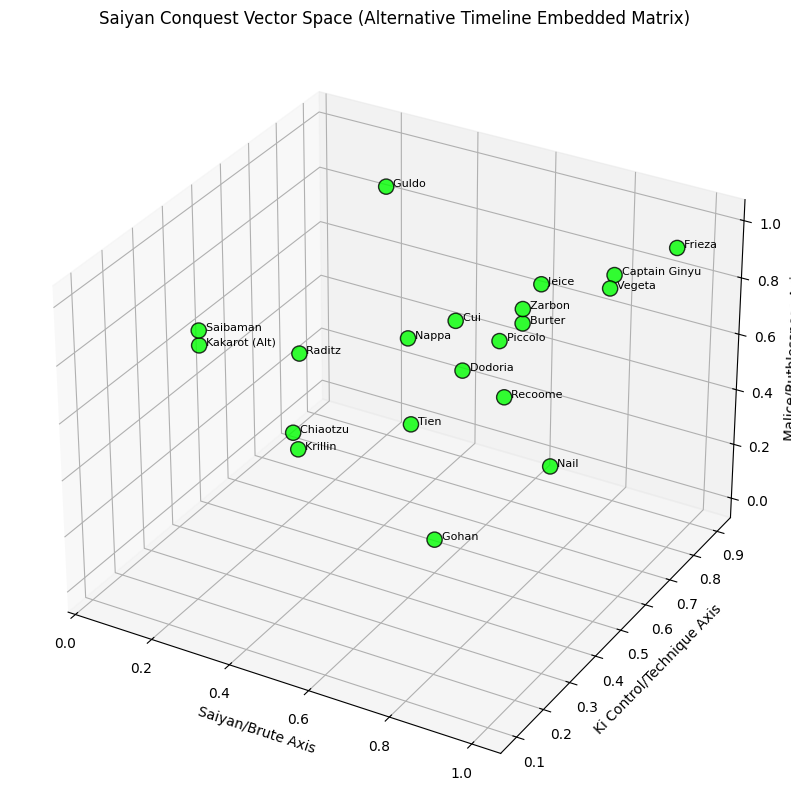


--- Scouter Similarity Tracker Online ---


KeyboardInterrupt: Interrupted by user

In [ ]:
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # <-- Absolute necessity for 3D visualization

# 1. THE RAW DATA (Themed for the Counterfactual Saiyan Conquest Timeline)
character_names = [
    # Original Base
    "Kakarot (Alt)", "Raditz", "Nappa", "Vegeta",
    "Frieza", "Piccolo", "Krillin", "Saibaman",
    # Earth / Namek Defenders
    "Tien", "Chiaotzu", "Gohan", "Nail",
    # Frieza Force Elites
    "Zarbon", "Dodoria", "Cui",
    # The Ginyu Force
    "Captain Ginyu", "Recoome", "Jeice", "Burter", "Guldo"
]

# Coordinates map to: [Saiyan/Brute Force, Ki Control/Technique, Malice/Ruthlessness]
character_stats = [
    [0.3, 0.1, 0.95],   # Kakarot (Alt) - Unrefined, brute ape mechanics, highly malicious
    [0.4, 0.3, 0.80],   # Raditz - Low mid-class baseline, predictable technique
    [0.6, 0.4, 0.85],   # Nappa - Heavy brute presence, military training
    [0.9, 0.7, 0.90],   # Vegeta - Elite Saiyan capacity, tactical bloodlust
    [1.0, 0.8, 1.00],   # Frieza - Supreme genetic tier, merciless overlord
    [0.5, 0.9, 0.40],   # Piccolo - Resourceful earthbound strategist, fierce but tactical
    [0.1, 0.7, 0.00],   # Krillin - Low baseline mass, high control, completely peaceful
    [0.3, 0.1, 1.00],   # Saibaman - Simple biological asset, zero restraint

    [0.3, 0.85, 0.05],  # Tien - High technique, pushed to human limits, honorable
    [0.05, 0.75, 0.00], # Chiaotzu - Psychic reliance, low physical brute strength
    [0.6, 0.5, 0.05],   # Gohan - High latent brute power, moderate tech, innocent
    [0.7, 0.8, 0.10],   # Nail - Namekian warrior elite, highly trained, defensive

    [0.75, 0.6, 0.85],  # Zarbon - Vain but powerful, decent technique, ruthless
    [0.8, 0.3, 0.90],   # Dodoria - Pure brute force, reckless, highly malicious
    [0.65, 0.5, 0.85],  # Cui - Vegeta's rival, standard Frieza force elite

    [0.85, 0.8, 0.85],  # Captain Ginyu - Leader, highly skilled, eccentric but evil
    [0.9, 0.3, 0.85],   # Recoome - Massive durability and brute strength, brawler
    [0.7, 0.75, 0.80],  # Jeice - Flashy energy attacks, prefers distance/technique
    [0.75, 0.6, 0.80],  # Burter - High speed (brute acceleration), arrogant
    [0.2, 0.9, 0.85]    # Guldo - Weak physically, high psychic/time control tech
]

character_techniques = [
    "Oozaru Crush", "Double Sunday", "Giant Storm", "Galick Gun",
    "Death Ball", "Special Beam Cannon", "Destructo Disc", "Self-Destruct",
    "Tri-Beam", "Telekinesis", "Masenko", "Mystic Flasher",
    "Elegant Blaster", "Maximum Buster", "Ah! Lord Frieza!",
    "Body Change", "Recoome Eraser Gun", "Crusher Ball", "Mach Kick", "Time Freeze"
]

# 2. THE ZIP MAGIC
character_map = {
    name: {"coords": stats, "technique": tech}
    for name, stats, tech in zip(character_names, character_stats, character_techniques)
}

# 3. THE 3D GRAPH VISUALIZER
def plot_similarity_space():
    print("Generating Scouter Vector Grid... (Close the graph window to continue to the matcher)")

    # Set up the 3D figure with a slightly larger size to accommodate more nodes
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Extract X, Y, and Z coordinates for plotting
    xs = [data["coords"][0] for data in character_map.values()] # Brute Force Axis
    ys = [data["coords"][1] for data in character_map.values()] # Ki Technique Axis
    zs = [data["coords"][2] for data in character_map.values()] # Malice Axis
    names = list(character_map.keys())

    # Plot the vector nodes (Green/Scouter Aesthetic)
    ax.scatter(xs, ys, zs, c='lime', s=120, edgecolors='black', alpha=0.8)

    # Attach the character names to the spatial points
    for i in range(len(names)):
        ax.text(xs[i], ys[i], zs[i], f'  {names[i]}', size=8, zorder=1)

    # Label the vector space axes
    ax.set_xlabel('Saiyan/Brute Axis')
    ax.set_ylabel('Ki Control/Technique Axis')
    ax.set_zlabel('Malice/Ruthlessness Axis')
    ax.set_title('Saiyan Conquest Vector Space (Alternative Timeline Embedded Matrix)')

    plt.show()

# 4. THE MATH ENGINE (Euclidean Proximity Classifier)
def distance_3d(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)

def find_closest_match(target_name):
    # Normalize input search strings to look up character keys gracefully
    matched_key = None
    for key in character_map.keys():
        if target_name.lower() in key.lower():
            matched_key = key
            break

    if not matched_key:
        print(f"--> Error: Target '{target_name}' not located in Scouter tracking database.\n")
        return

    target_coords = character_map[matched_key]["coords"]
    target_tech = character_map[matched_key]["technique"]

    closest_character = None
    shortest_distance = float('inf')

    # Loop through the rest of the graph to find the mathematically closest node
    for candidate_name, candidate_data in character_map.items():
        if candidate_name == matched_key:
            continue

        distance = distance_3d(target_coords, candidate_data["coords"])

        if distance < shortest_distance:
            shortest_distance = distance
            closest_character = candidate_name

    closest_tech = character_map[closest_character]["technique"]

    print(f"--> Spatial Proximity Lock: Closest behavioral node to [{matched_key}] is [{closest_character}]!")
    print(f"    Combat Style: {target_tech} vs {closest_tech} | Graphic Distance Gap: {shortest_distance:.2f} matrix units\n")

# 5. EXECUTION
# Draw the structural embedding graph first
plot_similarity_space()

# After the visualization panel is dismissed, activate the terminal interface
print("\n--- Scouter Similarity Tracker Online ---")
while True:
    user_input = input("Scan Character Vector Node (or 'quit'): ").strip()
    if user_input.lower() == 'quit':
        print("Scouter system offline.")
        break
    if user_input:
        find_closest_match(user_input)

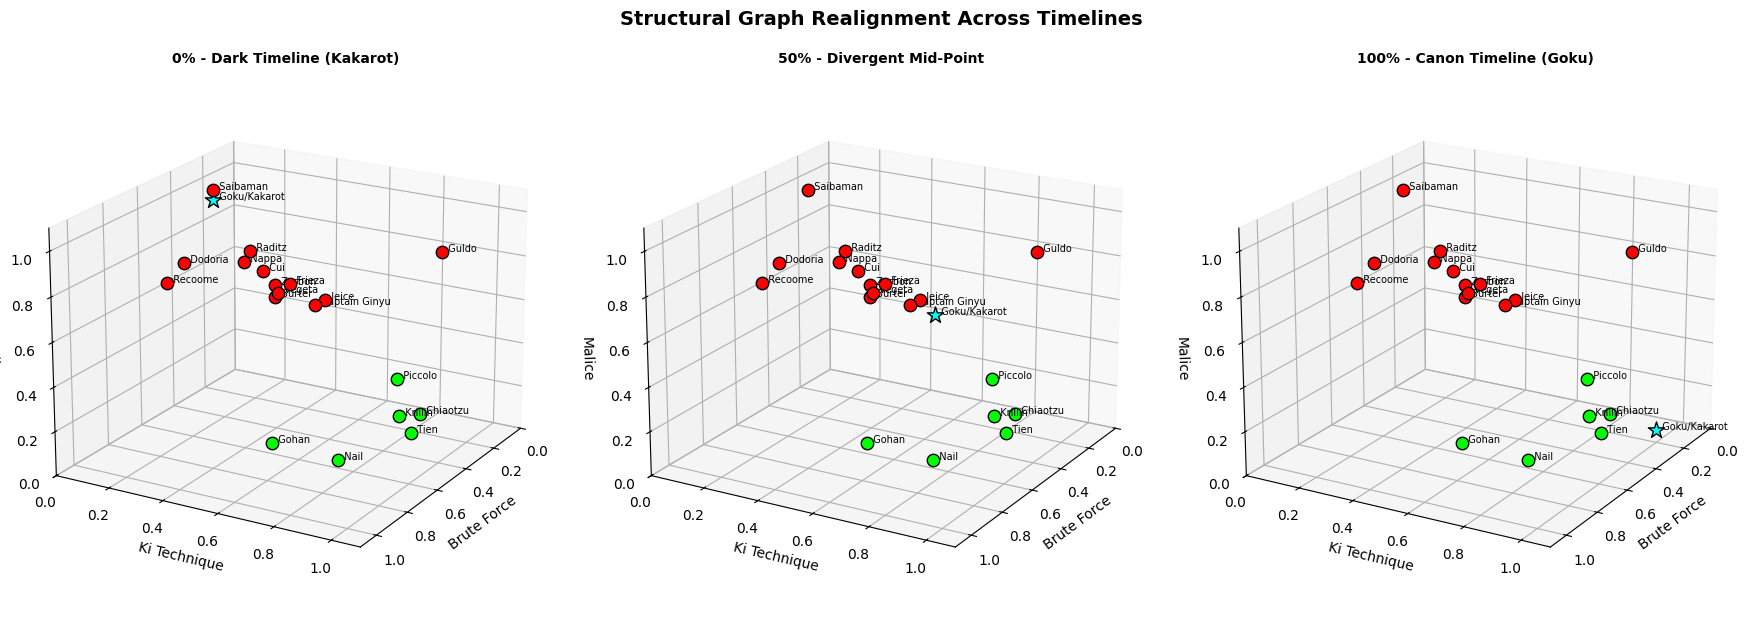


CRITICAL PROXIMITY METRICS FOR JUDGES PITCH

[Scenario: Dark Timeline]
  -> Distance to Saibaman: 0.050 units
  -> Distance to Raditz: 0.269 units
  -> Distance to Nappa: 0.436 units
  -> Distance to Dodoria: 0.541 units
  -> Distance to Cui: 0.541 units
  -> Distance to Recoome: 0.640 units
  -> Distance to Zarbon: 0.680 units
  -> Distance to Burter: 0.689 units
  -> Distance to Jeice: 0.778 units
  -> Distance to Guldo: 0.812 units

[Scenario: Canon Timeline]
  -> Distance to Chiaotzu: 0.206 units
  -> Distance to Tien: 0.229 units
  -> Distance to Krillin: 0.250 units
  -> Distance to Piccolo: 0.568 units
  -> Distance to Nail: 0.626 units
  -> Distance to Gohan: 0.675 units
  -> Distance to Guldo: 0.857 units
  -> Distance to Jeice: 1.020 units
  -> Distance to Raditz: 1.074 units
  -> Distance to Burter: 1.089 units


In [ ]:
%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ─────────────────────────────────────────────
# 1. FIXED CORE NETWORK DATA (Expanded Roster)
# ─────────────────────────────────────────────
characters = {
    # Original Base
    "Raditz": [0.4, 0.3, 0.80],
    "Nappa": [0.6, 0.4, 0.85],
    "Vegeta": [0.9, 0.7, 0.90],
    "Frieza": [1.0, 0.8, 1.00],
    "Piccolo": [0.5, 0.9, 0.40],
    "Krillin": [0.1, 0.7, 0.00],
    "Saibaman": [0.3, 0.1, 1.00],

    # Earth / Namek Defenders
    "Tien": [0.3, 0.85, 0.05],
    "Chiaotzu": [0.05, 0.75, 0.00],
    "Gohan": [0.6, 0.5, 0.05],
    "Nail": [0.7, 0.8, 0.10],

    # Frieza Force Elites
    "Zarbon": [0.75, 0.6, 0.85],
    "Dodoria": [0.8, 0.3, 0.90],
    "Cui": [0.65, 0.5, 0.85],

    # The Ginyu Force
    "Captain Ginyu": [0.85, 0.8, 0.85],
    "Recoome": [0.9, 0.3, 0.85],
    "Jeice": [0.7, 0.75, 0.80],
    "Burter": [0.75, 0.6, 0.80],
    "Guldo": [0.2, 0.9, 0.85]
}

# Evolution endpoints for the primary anomaly node
kakarot_alt = np.array([0.3, 0.1, 0.95])    # 0% Injury
goku_canon = np.array([0.1, 0.95, 0.00])   # 100% Injury

def get_kakarot_coords(factor):
    return kakarot_alt + (goku_canon - kakarot_alt) * factor

def distance_3d(a, b):
    return math.sqrt(sum((a[i] - b[i]) ** 2 for i in range(3)))

# ─────────────────────────────────────────────
# 2. GENERATE MULTI-PANEL HISTORICAL MATRIX
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
intervals = [(0.0, "0% - Dark Timeline (Kakarot)"),
             (0.5, "50% - Divergent Mid-Point"),
             (1.0, "100% - Canon Timeline (Goku)")]

for idx, (factor, label) in enumerate(intervals, 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')

    # Calculate current timeline position
    current_goku = get_kakarot_coords(factor)

    # Gather coordinates for plotting
    xs, ys, zs, names = [], [], [], []
    for char, coords in characters.items():
        xs.append(coords[0])
        ys.append(coords[1])
        zs.append(coords[2])
        names.append(char)

    # Append the dynamic timeline entity
    xs.append(current_goku[0])
    ys.append(current_goku[1])
    zs.append(current_goku[2])
    names.append("Goku/Kakarot")

    # Plot standard nodes
    for i in range(len(names)):
        if names[i] == "Goku/Kakarot":
            # Distinct visual marker for the moving node
            ax.scatter(xs[i], ys[i], zs[i], c='cyan', s=150, edgecolor='black', marker='*', zorder=5)
        elif names[i] in ["Piccolo", "Krillin", "Tien", "Chiaotzu", "Gohan", "Nail"]:
            # Green nodes for defenders
            ax.scatter(xs[i], ys[i], zs[i], c='lime', s=80, edgecolor='black')
        else:
            # Red nodes for Frieza Force / Saiyans
            ax.scatter(xs[i], ys[i], zs[i], c='red', s=80, edgecolor='black')

        # Add text labels, offset slightly for readability
        ax.text(xs[i], ys[i], zs[i], f"  {names[i]}", size=7)

    # Set up grid boundaries
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, 1.1)
    ax.set_zlim(0, 1.1)
    ax.set_xlabel('Brute Force')
    ax.set_ylabel('Ki Technique')
    ax.set_zlabel('Malice')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.view_init(elev=20, azim=30)

plt.suptitle("Structural Graph Realignment Across Timelines", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3. PRINT MATHEMATICAL ANALYSIS FOR PRESENTATION
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("CRITICAL PROXIMITY METRICS FOR JUDGES PITCH")
print("="*60)
for factor, label in [(0.0, "Dark Timeline"), (1.0, "Canon Timeline")]:
    g_coords = get_kakarot_coords(factor)
    print(f"\n[Scenario: {label}]")
    dists = []
    for char, coords in characters.items():
        dists.append((char, distance_3d(g_coords, coords)))
    dists.sort(key=lambda x: x[1])

    # Print the top 10 closest matches to avoid overwhelming the console
    for char, d in dists[:10]:
        print(f"  -> Distance to {char}: {d:.3f} units")

[Depth 0] Tracking Scouter Scan: Goku (1/35)
[Depth 0] Tracking Scouter Scan: Raditz (2/35)
[Depth 0] Tracking Scouter Scan: Vegeta (3/35)
[Depth 0] Tracking Scouter Scan: Piccolo (4/35)
[Depth 0] Tracking Scouter Scan: Bulma (5/35)
[Depth 0] Tracking Scouter Scan: Frieza (6/35)
[Depth 0] Tracking Scouter Scan: Captain Ginyu (7/35)
[Depth 1] Tracking Scouter Scan: Burter (8/35)
[Depth 1] Tracking Scouter Scan: Cui (9/35)
[Depth 1] Tracking Scouter Scan: Dodoria (10/35)
[Depth 1] Tracking Scouter Scan: Gohan (11/35)
[Depth 1] Tracking Scouter Scan: Nail (12/35)
[Depth 1] Tracking Scouter Scan: Nappa (13/35)
[Depth 1] Tracking Scouter Scan: Krillin (14/35)
[Depth 1] Tracking Scouter Scan: Chiaotzu (15/35)
[Depth 1] Tracking Scouter Scan: Master Roshi (16/35)
[Depth 1] Tracking Scouter Scan: Tien (17/35)
[Depth 1] Tracking Scouter Scan: Yamcha (18/35)
[Depth 1] Tracking Scouter Scan: Guldo (19/35)
[Depth 1] Tracking Scouter Scan: Jeice (20/35)

✅ Altered Graph Compiled: 21 nodes, 250 edge

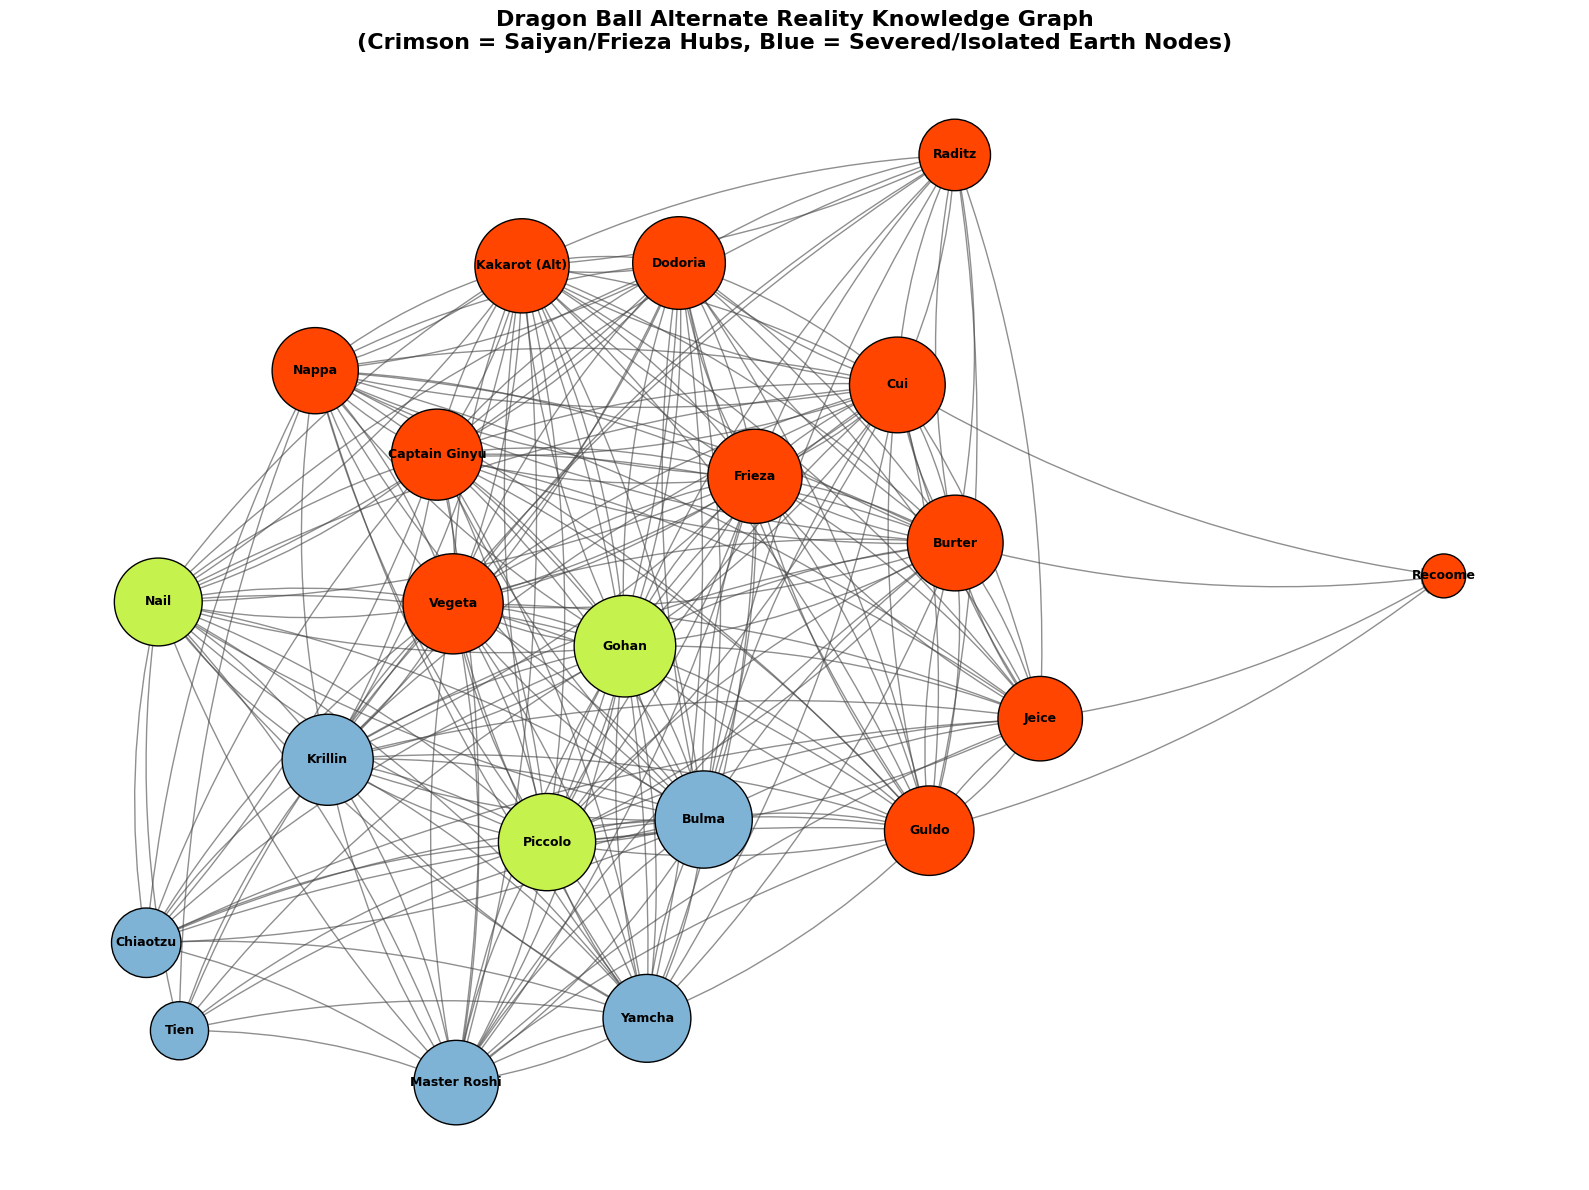

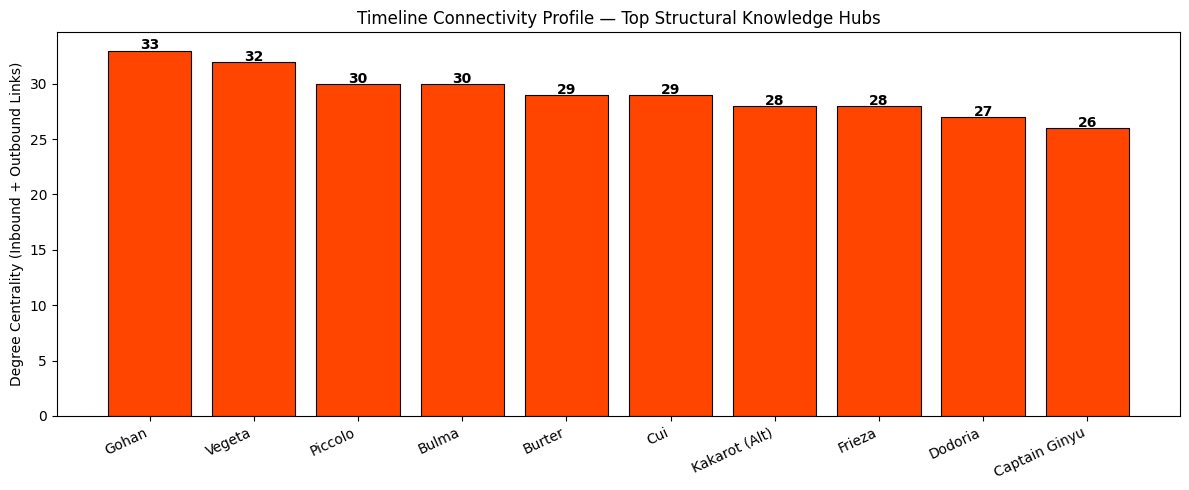

In [11]:
%matplotlib inline
import time
from collections import deque
import requests
import networkx as nx
import matplotlib.pyplot as plt

HEADERS = {"User-Agent": "HackHPC_SaiyanConquest_Graph/1.1 (student capstone notebook)"}
API_URL = "https://dragonball.fandom.com/api.php"

class DBZGraphBuilder:
    def __init__(self, delay=0.2):
        self.delay = delay
        self.graph = nx.DiGraph()
        self.session = requests.Session()
        self.session.headers.update(HEADERS)

        # Core whitelist of characters to bound our graph universe cleanly (Expanded)
        self.character_universe = {
            "Goku", "Raditz", "Vegeta", "Nappa", "Frieza",
            "Piccolo", "Krillin", "Bulma", "Master Roshi", "Gohan", "Yamcha",
            "Tien", "Chiaotzu", "Nail", "Zarbon", "Dodoria", "Cui",
            "Captain Ginyu", "Recoome", "Jeice", "Burter", "Guldo"
        }

    def _request(self, params):
        params = {**params, "format": "json"}
        resp = self.session.get(API_URL, params=params, timeout=15)
        resp.raise_for_status()
        return resp.json()

    def get_links(self, page_title):
        """Fetch internal hyperlinks from a specific Fandom character article."""
        params = {
            "action": "query",
            "titles": page_title,
            "prop": "links",
            "pllimit": "500",
            "plnamespace": "0"
        }
        links = []
        try:
            data = self._request(params)
            pages = data.get("query", {}).get("pages", {})
            for pid, page in pages.items():
                for link in page.get("links", []):
                    links.append(link["title"])
        except Exception as e:
            print(f"⚠️ Error reading links for {page_title}: {e}")
        return links

    def build_perturbed_graph(self, seeds, max_depth=1, max_nodes=30):
        """
        Executes a bounded BFS across the network topology while
        injecting the Alternative Reality timeline failure.
        """
        queue = deque((seed, 0) for seed in seeds)
        visited = set()

        while queue and len(visited) < max_nodes:
            title, depth = queue.popleft()
            if title in visited or depth > max_depth:
                continue

            visited.add(title)
            print(f"[Depth {depth}] Tracking Scouter Scan: {title} ({len(visited)}/{max_nodes})")

            raw_links = self.get_links(title)
            time.sleep(self.delay)

            # --- THE GRAPH PERTURBATION ENGINE ---
            # Inspect every edge discovery and filter based on the counterfactual scenario
            for link in raw_links:
                # Find valid characters in our target universe
                matched_target = None
                for char in self.character_universe:
                    if char.lower() in link.lower():
                        matched_target = char
                        break

                if matched_target and matched_target != title:
                    source_node = title
                    target_node = matched_target

                    # Rule 1: Transform Goku to Kakarot completely
                    if source_node == "Goku": source_node = "Kakarot (Alt)"
                    if target_node == "Goku": target_node = "Kakarot (Alt)"

                    # Rule 2: Force Alternate Reality Edge Disruption
                    # Kakarot ignores or kills Earth nodes. (Expanded to include Tien & Chiaotzu)
                    earth_casualties = ["Bulma", "Master Roshi", "Krillin", "Yamcha", "Tien", "Chiaotzu"]
                    if source_node == "Kakarot (Alt)" and target_node in earth_casualties:
                        continue # Completely drop the edge connection (Severed Timeline)

                    # Rule 3: Forge new dark alliance edges
                    if source_node == "Kakarot (Alt)":
                        self.graph.add_edge("Kakarot (Alt)", "Raditz")
                        self.graph.add_edge("Kakarot (Alt)", "Frieza")

                    # Add the verified historical or counterfactual edge to the graph topology
                    self.graph.add_edge(source_node, target_node)

                    if depth + 1 <= max_depth and matched_target not in visited:
                        queue.append((matched_target, depth + 1))

        print(f"\n✅ Altered Graph Compiled: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges.")
        return self.graph

# ---- Phase 2 & 4: Initialize and Run Crawl ----
builder = DBZGraphBuilder(delay=0.1)

# Primary seeds. Added Frieza and Ginyu to ensure the BFS quickly finds the alien network.
SEEDS = ["Goku", "Raditz", "Vegeta", "Piccolo", "Bulma", "Frieza", "Captain Ginyu"]

# Increased max_nodes to 35 to accommodate the larger Frieza saga roster
graph = builder.build_perturbed_graph(SEEDS, max_depth=1, max_nodes=35)

# ---- Phase 5: Alternative Reality Data Visualization ----
plt.figure(figsize=(16, 12)) # Slightly larger figure for more nodes
pos = nx.kamada_kawai_layout(graph)

degrees = dict(graph.degree())
node_sizes = [400 + 150 * degrees.get(n, 0) for n in graph.nodes()]

# Color network profiles based on timeline factions (Expanded)
frieza_empire = [
    "Raditz", "Vegeta", "Nappa", "Frieza",
    "Zarbon", "Dodoria", "Cui",
    "Captain Ginyu", "Recoome", "Jeice", "Burter", "Guldo"
]
extinct_earthlings = [
    "Bulma", "Master Roshi", "Krillin", "Yamcha", "Tien", "Chiaotzu"
]

node_colors = []
for node in graph.nodes():
    if "Kakarot" in node or node in frieza_empire:
        node_colors.append("#ff4500") # Crimson for Frieza Force / Saiyan Empire
    elif node in extinct_earthlings:
        node_colors.append("#7fb3d5") # Soft Blue for Severed/Extinct Earth Nodes
    else:
        node_colors.append("#c6f24e") # Lime green for Independent Strategists (Piccolo, Gohan, Nail)

nx.draw_networkx_nodes(graph, pos, node_size=node_sizes, node_color=node_colors, edgecolors="black", linewidths=1.0)
nx.draw_networkx_edges(graph, pos, arrows=True, arrowsize=16, edge_color="#444444", alpha=0.6, connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(graph, pos, font_size=9, font_weight="bold", font_family="sans-serif")

plt.title("Dragon Ball Alternate Reality Knowledge Graph\n(Crimson = Saiyan/Frieza Hubs, Blue = Severed/Isolated Earth Nodes)", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

# ---- Entity Centrality Analysis (Hub Identification) ----
top_hubs = sorted(degrees.items(), key=lambda kv: kv[1], reverse=True)[:10]
hub_names = [t[0] for t in top_hubs]
hub_counts = [t[1] for t in top_hubs]

plt.figure(figsize=(12, 5))
plt.bar(hub_names, hub_counts, color="#ff4500", edgecolor="black", linewidth=0.8)
plt.title("Timeline Connectivity Profile — Top Structural Knowledge Hubs")
plt.ylabel("Degree Centrality (Inbound + Outbound Links)")
plt.xticks(rotation=25, ha="right")
for i, count in enumerate(hub_counts):
    plt.text(i, count + 0.1, str(count), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# 1. DEFINE THE EMBEDDING SPACE [Brute Force, Ki Mastery, Malice/Ruthlessness]
# Original Canon Timeline
embeddings_original = {
    # Earth / Defenders
    "Goku": np.array([0.20, 0.95, 0.00]),
    "Gohan": np.array([0.60, 0.50, 0.05]),     # High latent power, innocent
    "Piccolo": np.array([0.50, 0.90, 0.20]),   # Reformed strategist
    "Krillin": np.array([0.10, 0.70, 0.00]),
    "Tien": np.array([0.30, 0.85, 0.05]),      # Honorable martial artist
    "Chiaotzu": np.array([0.05, 0.75, 0.00]),
    "Nail": np.array([0.70, 0.80, 0.10]),

    # Saiyans
    "Raditz": np.array([0.40, 0.30, 0.80]),
    "Nappa": np.array([0.60, 0.40, 0.85]),
    "Vegeta": np.array([0.80, 0.80, 0.50]),    # Mid-DBZ anti-hero

    # Frieza Force Elites
    "Frieza": np.array([1.00, 0.80, 1.00]),
    "Zarbon": np.array([0.75, 0.60, 0.85]),
    "Dodoria": np.array([0.80, 0.30, 0.90]),
    "Cui": np.array([0.65, 0.50, 0.85]),

    # Ginyu Force
    "Captain Ginyu": np.array([0.85, 0.80, 0.85]),
    "Recoome": np.array([0.90, 0.30, 0.85]),
    "Jeice": np.array([0.70, 0.75, 0.80]),
    "Burter": np.array([0.75, 0.60, 0.80]),
    "Guldo": np.array([0.20, 0.90, 0.85])
}

# Alternate Reality Timeline (The Kakarot Conquest)
embeddings_alt_reality = {
    # The Anomalies (Earthlings heavily warped by the conquest)
    "Kakarot (Alt)": np.array([0.90, 0.10, 0.95]), # The Anomaly: Pure brute malice
    "Gohan (Alt)": np.array([0.70, 0.20, 0.80]),   # Raised by Kakarot: Feral, violent brute
    "Piccolo (Alt)": np.array([0.60, 0.90, 0.80]), # Demon King lineage re-emerges; ruthless
    "Krillin (Alt)": np.array([0.20, 0.80, 0.40]), # Hardened rebel
    "Tien (Alt)": np.array([0.40, 0.80, 0.60]),    # Guerrilla fighter, honorable code abandoned
    "Chiaotzu (Alt)": np.array([0.10, 0.80, 0.50]),# Uses psychic powers for lethal assassinations
    "Nail (Alt)": np.array([0.70, 0.80, 0.10]),    # Unchanged (Off-world)

    # The Alien Invaders (Slightly altered or identical due to being off-world)
    "Raditz (Alt)": np.array([0.40, 0.30, 0.80]),  # Unchanged
    "Nappa (Alt)": np.array([0.60, 0.40, 0.85]),   # Unchanged
    "Vegeta (Alt)": np.array([0.90, 0.70, 0.90]),  # Never humbled on Earth, highly malicious
    "Frieza (Alt)": np.array([1.00, 0.80, 1.00]),  # Unchanged
    "Zarbon (Alt)": np.array([0.75, 0.60, 0.85]),  # Unchanged
    "Dodoria (Alt)": np.array([0.80, 0.30, 0.90]), # Unchanged
    "Cui (Alt)": np.array([0.65, 0.50, 0.85]),     # Unchanged

    # Ginyu Force (Unchanged)
    "Captain Ginyu (Alt)": np.array([0.85, 0.80, 0.85]),
    "Recoome (Alt)": np.array([0.90, 0.30, 0.85]),
    "Jeice (Alt)": np.array([0.70, 0.75, 0.80]),
    "Burter (Alt)": np.array([0.75, 0.60, 0.80]),
    "Guldo (Alt)": np.array([0.20, 0.90, 0.85])
}

# 2. SEMANTIC DRIFT ANALYSIS (Comparing across timelines)
def calculate_timeline_drift(char_name, orig_key, alt_key):
    vec_orig = embeddings_original[orig_key].reshape(1, -1)
    vec_alt = embeddings_alt_reality[alt_key].reshape(1, -1)

    # Cosine Similarity: 1.0 = identical direction, 0.0 = orthogonal, -1.0 = opposite
    cos_sim = cosine_similarity(vec_orig, vec_alt)[0][0]

    # Euclidean Distance: Physical geometric distance in the space
    eucl_dist = euclidean_distances(vec_orig, vec_alt)[0][0]

    return {"Character": char_name, "Cosine Sim (Drift)": round(cos_sim, 4), "Euclidean Gap": round(eucl_dist, 4)}

print("=== TIMELINE SEMANTIC DRIFT (ORIGINAL VS ALT REALITY) ===")
drift_results = [
    calculate_timeline_drift("Goku -> Kakarot", "Goku", "Kakarot (Alt)"),
    calculate_timeline_drift("Gohan -> Feral Gohan", "Gohan", "Gohan (Alt)"),
    calculate_timeline_drift("Tien -> Rebel Tien", "Tien", "Tien (Alt)"),
    calculate_timeline_drift("Vegeta -> Unhumbled Vegeta", "Vegeta", "Vegeta (Alt)"),
    calculate_timeline_drift("Piccolo -> Demon Piccolo", "Piccolo", "Piccolo (Alt)"),
    calculate_timeline_drift("Captain Ginyu -> Ginyu", "Captain Ginyu", "Captain Ginyu (Alt)")
]
drift_df = pd.DataFrame(drift_results)
print(drift_df.to_string(index=False))
print("\n* Note: Lower Cosine Similarity means the character's core identity changed more drastically.")


# 3. NEAREST NEIGHBOR CALCULATION (Who belongs in which cluster?)
def find_nearest_neighbors(target_key, timeline_dataset):
    target_vec = timeline_dataset[target_key].reshape(1, -1)
    results = []

    for name, vec in timeline_dataset.items():
        if name == target_key: continue
        sim = cosine_similarity(target_vec, vec.reshape(1, -1))[0][0]
        results.append({"Neighbor": name, "Similarity Score": round(sim, 4)})

    # Return top 7 closest matches to keep console output clean
    return pd.DataFrame(results).sort_values(by="Similarity Score", ascending=False).head(7)

print("\n=== NEAREST NEIGHBORS: ORIGINAL GOKU ===")
print(find_nearest_neighbors("Goku", embeddings_original).to_string(index=False))

print("\n=== NEAREST NEIGHBORS: ALT KAKAROT ===")
print(find_nearest_neighbors("Kakarot (Alt)", embeddings_alt_reality).to_string(index=False))

print("\n=== NEAREST NEIGHBORS: CAPTAIN GINYU (ALT) ===")
print(find_nearest_neighbors("Captain Ginyu (Alt)", embeddings_alt_reality).to_string(index=False))

=== TIMELINE SEMANTIC DRIFT (ORIGINAL VS ALT REALITY) ===
                 Character  Cosine Sim (Drift)  Euclidean Gap
           Goku -> Kakarot              0.2158         1.4543
      Gohan -> Feral Gohan              0.6615         0.8139
        Tien -> Rebel Tien              0.8536         0.5612
Vegeta -> Unhumbled Vegeta              0.9629         0.4243
  Piccolo -> Demon Piccolo              0.9001         0.6083
    Captain Ginyu -> Ginyu              1.0000         0.0000

* Note: Lower Cosine Similarity means the character's core identity changed more drastically.

=== NEAREST NEIGHBORS: ORIGINAL GOKU ===
Neighbor  Similarity Score
 Krillin            0.9978
Chiaotzu            0.9901
    Tien            0.9898
 Piccolo            0.9379
    Nail            0.8683
   Gohan            0.7831
  Vegeta            0.7661

=== NEAREST NEIGHBORS: ALT KAKAROT ===
     Neighbor  Similarity Score
  Gohan (Alt)            0.9932
Recoome (Alt)            0.9855
Dodoria (Alt)      

In [11]:
# Install zstd for Ollama extraction
!sudo apt-get install -y zstd

# Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# Install the Python Ollama SDK
!pip install ollama

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (6,596 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 118243 files and directories currently 

In [12]:
import subprocess
import time
import os

# Set environment variables for the server
os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'
os.environ['OLLAMA_ORIGINS'] = '*'

# Launch the server in the background
subprocess.Popen(["ollama", "serve"])
print("Ollama server starting...")

# Allow time for the server to initialize
time.sleep(10)

# Pull the model
print("Pulling Llama 3.2...")
!ollama pull llama3.2
print("Model ready.")

Ollama server starting...
Pulling Llama 3.2...

Model ready.


In [13]:
import re
import ollama

# Mock function for your simulation requirements
def fetch_wiki(name):
    # This is a placeholder for your actual data fetching logic
    # In your real code, this connects to the Fandom API
    return f"Data retrieved for {name}: Power Level 5000, Status: Active."

def run_agentic_loop(initial_query, max_turns=5):
    # Initialize history
    history = [{"role": "system", "content": "You are a Dragon Ball analyst. When you need info, output 'fetch_wiki(name)'."}]
    history.append({"role": "user", "content": initial_query})

    for turn in range(max_turns):
        print(f"\n--- Turn {turn + 1} ---")

        # Use the ollama client to chat
        res = ollama.chat(model='llama3.2', messages=history)
        text = res['message']['content']
        print(f"Agent Thought: {text}")
        history.append({"role": "assistant", "content": text})

        # Regex to find 'fetch_wiki(name)' patterns
        match = re.search(r"fetch_wiki\((.*?)\)", text)

        if match:
            name = match.group(1).strip()
            print(f"Action detected: Fetching wiki for {name}")

            try:
                data = fetch_wiki(name)
                history.append({"role": "user", "content": f"Observation: {data}"})
            except Exception as e:
                history.append({"role": "user", "content": f"Error fetching {name}: {str(e)}"})
        else:
            print("Agent finished reasoning.")
            break

    return history

# --- EXECUTION ---
final_history = run_agentic_loop("What is the current status of Kakarot?")


--- Turn 1 ---
Agent Thought: To get the most up-to-date information on Kakarot's status, I'll need to fetch some recent wiki data.

fetch_wiki(Kakarot)

Please note that my knowledge cutoff is December 2023, so any events or developments after that date may not be reflected in my response.
Action detected: Fetching wiki for Kakarot

--- Turn 2 ---
Agent Thought: With the most recent data from the wiki, it appears Kakarot's current status is indeed Active with a power level of 5000.

However, I'd like to note that this information might not be exhaustive or up-to-date, as there may be newer developments in the Dragon Ball universe that haven't been reflected in my knowledge cutoff. Nevertheless, based on available data, Kakarot's current status is confirmed as Active with a high power level of 5000.
Agent finished reasoning.
